In [2]:
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [6]:
raw_path = "../data/raw/"
df = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)

n_cols = df.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df.columns = columns
df.head()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1.0


In [7]:
#osnovni, brzi pregled podataka
#dimenzije
print("Dimenzije dataset-a:", df.shape)
#provjera nedostajucih vrijednosti
print("Nedostajući podaci po koloni:\n", df.isnull().sum())
#statistika numerickih atributa
print("Opis numeričkih kolona:\n", df.iloc[:,1:].describe())
#broj MUSK i NON-MUSK molekula
num_musk = sum(df['ID'].str.startswith('MUSK'))
num_non_musk = sum(df['ID'].str.startswith('NON-MUSK'))
print(f"MUSK: {num_musk}, NON-MUSK: {num_non_musk}")

Dimenzije dataset-a: (6598, 169)
Nedostajući podaci po koloni:
 ID          0
attr_1      0
attr_2      0
attr_3      0
attr_4      0
           ..
attr_164    0
attr_165    0
attr_166    0
attr_167    0
attr_168    0
Length: 169, dtype: int64
Opis numeričkih kolona:
             attr_2       attr_3       attr_4       attr_5       attr_6  \
count  6598.000000  6598.000000  6598.000000  6598.000000  6598.000000   
mean     58.945135  -119.128524   -73.146560    -0.628372  -103.533495   
std      53.249007    90.813375    67.956235    80.444617    64.387559   
min     -31.000000  -199.000000  -167.000000  -114.000000  -118.000000   
25%      37.000000  -193.000000  -137.000000   -70.000000  -117.000000   
50%      44.000000  -149.000000   -99.000000   -25.000000  -117.000000   
75%      53.000000   -95.000000   -19.000000    42.000000  -116.000000   
max     292.000000    95.000000    81.000000   161.000000   325.000000   

            attr_7       attr_8       attr_9      attr_10      a

In [9]:
#dodavanje target kolone u kojoj 1 oznacava MUSK, a 0 NON-MUSK
df['target'] = df['ID'].apply(lambda x: 1 if x.startswith('MUSK') else 0)

In [10]:
df[['ID', 'target']].head(10)

,ID,target
0,MUSK-211,1
1,MUSK-211,1
2,MUSK-211,1
3,MUSK-211,1
4,MUSK-211,1
5,MUSK-211,1
6,MUSK-211,1
7,MUSK-211,1
8,MUSK-211,1
9,MUSK-211,1


In [11]:
df[['ID', 'target']].tail(10)

,ID,target
6588,NON-MUSK-jp13,0
6589,NON-MUSK-jp13,0
6590,NON-MUSK-jp13,0
6591,NON-MUSK-jp13,0
6592,NON-MUSK-jp13,0
6593,NON-MUSK-jp13,0
6594,NON-MUSK-jp13,0
6595,NON-MUSK-jp13,0
6596,NON-MUSK-jp13,0
6597,NON-MUSK-jp13,0


In [15]:
X = df.drop(columns=['ID', 'target'])
X = X.select_dtypes(include=[np.number]) #uzimamo samo numericke vrijednosti
y = df['target']

In [16]:
print(X.isnull().sum().sum())

0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
n_components = 20
pca = PCA(n_components=n_components)

In [20]:
X_train_pca = pca.fit_transform(X_train_scaled)  
X_test_pca = pca.transform(X_test_scaled)       

In [21]:
print(pca.explained_variance_ratio_.sum()) #koliko ukupne informacije zadrzavamo u 20 komponenti, 86% varijansa

0.8631437079934439


Test skup se transformiše pomoću istih parametara (transform), bez ponovnog fitovanja, kako bi se izbjeglo data leakage i nerealno optimistični rezultati.

In [22]:
pca_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
# trening set
df_train_pca = pd.DataFrame(X_train_pca, columns=pca_names)
df_train_pca['target'] = y_train.values

# test set
df_test_pca = pd.DataFrame(X_test_pca, columns=pca_names)
df_test_pca['target'] = y_test.values

In [23]:
df_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,0.022970,-5.967714,3.897079,-2.747386,-0.085047,-0.161063,1.698362,0.300938,-3.455586,-2.220829,...,-0.859496,-1.185140,0.004086,-0.861604,-0.255883,0.775052,-0.081906,-0.206108,1.020054,1
1,-6.307603,2.776998,-2.178500,3.691180,3.078572,-2.642299,-0.326453,-1.331641,1.550033,0.049918,...,-0.351265,0.078146,0.614784,-0.527960,1.326518,2.061110,0.072384,-1.891768,0.356325,0
2,-8.326647,1.187097,-0.286650,0.333710,2.536841,-3.434837,-0.460276,-2.905680,-2.660530,-0.057532,...,-1.517514,-0.395067,-2.050341,1.111680,-0.381063,2.040566,-2.164802,1.283977,1.849358,0
3,-10.498265,1.882161,1.427111,-2.810309,-1.721857,5.795352,1.005833,1.097154,0.749268,-1.051313,...,-1.561639,1.805755,1.080687,0.417638,4.242951,-0.195641,-0.656571,-0.642841,-0.150338,0
4,7.808847,4.512286,-1.679613,3.143184,-1.941887,0.832991,-3.178764,-0.540306,-2.283444,1.685272,...,-0.173616,0.763809,-0.789098,0.671505,0.246289,-0.597793,-1.087424,-2.200030,0.208866,0


In [24]:
df_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-9.334293,1.986676,3.765961,2.708791,-2.368736,0.067776,-0.130601,-1.754508,-1.315318,0.843006,...,-0.406085,-1.275452,2.499138,0.028492,1.064394,2.643639,0.641979,1.833715,-1.360819,0
1,6.476571,2.221341,3.841941,0.423201,-0.238252,0.053538,0.551522,1.885884,0.117160,-0.676968,...,-0.211489,-0.644050,0.212805,-0.801836,1.922165,0.807173,-0.158996,1.307788,-0.129138,0
2,5.051063,3.302757,3.702442,1.457333,-0.857868,1.247921,-1.986760,1.718034,-2.187353,1.476311,...,-1.922590,2.658798,-2.581072,-0.596020,2.183521,0.955168,0.114653,-1.106809,-0.169177,0
3,6.440444,3.484844,3.359795,1.751995,-1.714406,-0.409853,-3.992152,1.492438,-0.391316,-2.143872,...,0.543812,-0.272968,-2.929459,0.074060,-0.373334,3.145976,3.708359,-0.756893,0.969144,0
4,-9.538525,1.953999,1.971120,-3.419771,-1.296818,4.244512,0.901099,0.596071,-1.231705,-0.069473,...,-0.586386,-0.844646,0.335961,-0.632594,0.909917,-1.852995,-0.807652,-0.365419,-0.653273,1


In [25]:
print("Varijansa po komponenti:")
explained_vars = zip(pca_names, pca.explained_variance_ratio_)
for name, var in explained_vars:
    print(f"{name}: {round(var * 100, 2)}%")

Varijansa po komponenti:
PC1: 29.1%
PC2: 17.84%
PC3: 4.88%
PC4: 4.34%
PC5: 3.45%
PC6: 3.14%
PC7: 2.93%
PC8: 2.67%
PC9: 2.43%
PC10: 2.35%
PC11: 1.86%
PC12: 1.81%
PC13: 1.59%
PC14: 1.43%
PC15: 1.32%
PC16: 1.26%
PC17: 1.12%
PC18: 1.06%
PC19: 0.88%
PC20: 0.87%


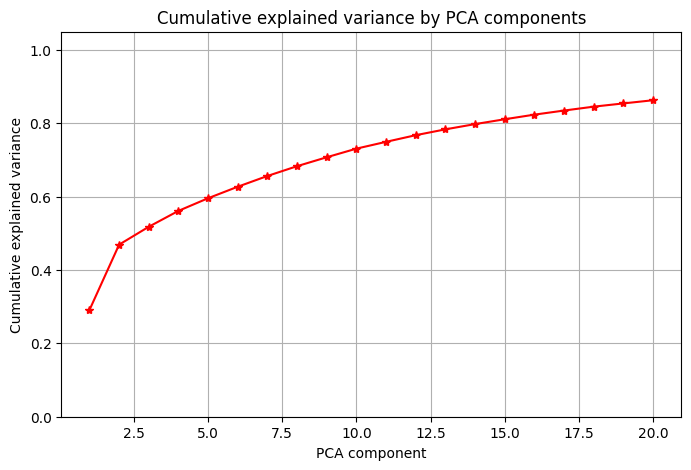

In [26]:
import matplotlib.pyplot as plt
cumsum_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, n_components+1), cumsum_variance_ratio, marker='*', color='red')
plt.xlabel('PCA component')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance by PCA components')
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

Za smanjenje dimenzionalnosti 168 numeričkih atributa koristila sam PCA, koja transformiše originalne atribute u linearno nekorelirane komponente.

Odabrano je 20 komponenti, što objašnjava ~86% ukupne varijanse i predstavlja kompromis između očuvanja informacija i smanjenja kompleksnosti modela.

In [27]:
processed_path = "../data/processed"
df_train_pca.to_csv(os.path.join(processed_path, "df_train_pca.csv"), index=False)
df_test_pca.to_csv(os.path.join(processed_path, "df_test_pca.csv"), index=False)

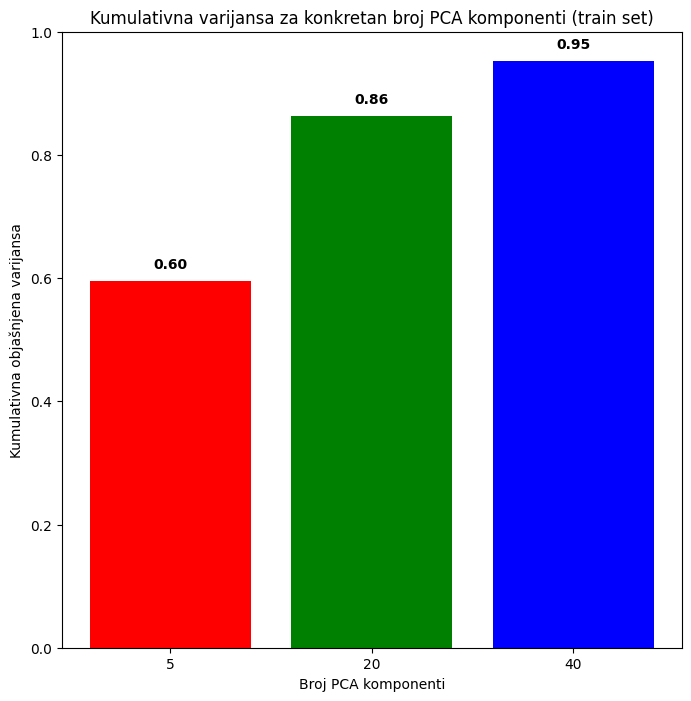

In [28]:
#eksperimentisanje
max_components = 40
pca_full = PCA(n_components=max_components)

X_train_pca_full = pca_full.fit_transform(X_train_scaled)
cumsum_var_train = np.cumsum(pca_full.explained_variance_ratio_)
components_to_plot = [5, 20, 40]
cumulative_variances = [cumsum_var_train[n-1] for n in components_to_plot]

plt.figure(figsize=(8,8))
plt.bar([str(n) for n in components_to_plot], cumulative_variances, color=['red', 'green', 'blue'])
plt.xlabel('Broj PCA komponenti')
plt.ylabel('Kumulativna objašnjena varijansa')
plt.title('Kumulativna varijansa za konkretan broj PCA komponenti (train set)')
plt.ylim(0, 1)
for i, v in enumerate(cumulative_variances):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()